# DAA Lab 1: Algorithm Efficiency Analysis

## Comparative Study of Algorithm Efficiency and Performance Analysis

This notebook implements and compares the performance of various sorting and Fibonacci algorithms.

In [1]:
import sys, os, time, random, statistics, tracemalloc
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, os.path.dirname(os.getcwd()))

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## 1. Sorting Algorithms

| Algorithm | Best Case | Average Case | Worst Case | Space | Stable |
|-----------|-----------|--------------|------------|-------|--------|
| Bubble Sort | O(n) | O(n²) | O(n²) | O(1) | Yes |
| Insertion Sort | O(n) | O(n²) | O(n²) | O(1) | Yes |
| Merge Sort | O(n log n) | O(n log n) | O(n log n) | O(n) | Yes |
| Quick Sort | O(n log n) | O(n log n) | O(n²) | O(log n) | No |

### 1.1 Bubble Sort

**Description:** Repeatedly steps through the list, compares adjacent elements and swaps them if they are in the wrong order. The largest unsorted element 'bubbles up' to its correct position on each pass.

**Input:** List of n comparable elements
**Output:** List sorted in ascending order

**Complexity:**
- Best Case: O(n) - already sorted (with early exit)
- Average Case: O(n²)
- Worst Case: O(n²) - reverse sorted
- Space Complexity: O(1)

**Advantages:** Simple, stable, adaptive
**Limitations:** Very slow for large datasets

**Application Scenarios:** Educational purposes, small datasets, nearly sorted data

**Pseudocode:**
```
ALGORITHM BubbleSort(A, n)
  FOR i = 0 TO n-2
    swapped = FALSE
    FOR j = 0 TO n-2-i
      IF A[j] > A[j+1]
        SWAP A[j], A[j+1]
        swapped = TRUE
    IF swapped == FALSE
      BREAK
  RETURN A
```

In [2]:
def bubble_sort(arr):
    """Sorts a list in ascending order using Bubble Sort.
    Returns (sorted_list, comparisons).
    """
    a = arr.copy()
    n = len(a)
    comparisons = 0
    for i in range(n - 1):
        swapped = False
        for j in range(n - 1 - i):
            comparisons += 1
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swapped = True
        if not swapped:
            break
    return a, comparisons

sample = [64, 34, 25, 12, 22, 11, 90]
sorted_arr, comps = bubble_sort(sample)
print(f'Sorted: {sorted_arr}')
print(f'Comparisons: {comps}')

Sorted: [11, 12, 22, 25, 34, 64, 90]
Comparisons: 21


### 1.2 Insertion Sort

**Description:** Builds the sorted list one element at a time by taking each element and inserting it into its correct position among the already-sorted elements to its left.

**Input:** List of n comparable elements
**Output:** List sorted in ascending order

**Complexity:**
- Best Case: O(n) - already sorted
- Average Case: O(n²)
- Worst Case: O(n²) - reverse sorted
- Space Complexity: O(1)

**Advantages:** Simple, stable, adaptive, online algorithm
**Limitations:** O(n²) for large datasets

**Application Scenarios:** Small datasets, nearly sorted data, online sorting

**Pseudocode:**
```
ALGORITHM InsertionSort(A, n)
  FOR i = 1 TO n-1
    key = A[i]
    j = i - 1
    WHILE j >= 0 AND A[j] > key
      A[j+1] = A[j]
      j = j - 1
    A[j+1] = key
  RETURN A
```

In [3]:
def insertion_sort(arr):
    """Sorts a list in ascending order using Insertion Sort.
    Returns (sorted_list, comparisons).
    """
    a = arr.copy()
    comparisons = 0
    for i in range(1, len(a)):
        key = a[i]
        j = i - 1
        while j >= 0:
            comparisons += 1
            if a[j] > key:
                a[j + 1] = a[j]
                j -= 1
            else:
                break
        a[j + 1] = key
    return a, comparisons

sample = [64, 34, 25, 12, 22, 11, 90]
sorted_arr, comps = insertion_sort(sample)
print(f'Sorted: {sorted_arr}')
print(f'Comparisons: {comps}')

Sorted: [11, 12, 22, 25, 34, 64, 90]
Comparisons: 16


### 1.3 Merge Sort (Divide and Conquer)

**Description:** Recursively splits the list into two halves, sorts each half, and merges the two sorted halves into a single sorted list.

**Input:** List of n comparable elements
**Output:** List sorted in ascending order

**Complexity:**
- Best Case: O(n log n)
- Average Case: O(n log n)
- Worst Case: O(n log n)
- Space Complexity: O(n)

**Advantages:** Guaranteed O(n log n), stable, predictable
**Limitations:** Requires O(n) extra space

**Application Scenarios:** Large datasets, external sorting, when stability is required

**Pseudocode:**
```
ALGORITHM MergeSort(A, left, right)
  IF left < right
    mid = (left + right) / 2
    MergeSort(A, left, mid)
    MergeSort(A, mid+1, right)
    Merge(A, left, mid, right)

ALGORITHM Merge(A, left, mid, right)
  Create temp arrays L = A[left..mid], R = A[mid+1..right]
  i = j = 0, k = left
  WHILE i < len(L) AND j < len(R)
    IF L[i] <= R[j]: A[k] = L[i]; i++
    ELSE: A[k] = R[j]; j++
    k++
  Copy remaining elements of L and R into A
```

In [4]:
def merge_sort(arr):
    """Sorts a list in ascending order using Merge Sort.
    Returns (sorted_list, comparisons).
    """
    a = arr.copy()
    comps = [0]  # mutable counter for nested function
    result = _merge_sort(a, comps)
    return result, comps[0]

def _merge_sort(a, comps):
    if len(a) <= 1:
        return a
    mid = len(a) // 2
    left = _merge_sort(a[:mid], comps)
    right = _merge_sort(a[mid:], comps)
    return _merge(left, right, comps)

def _merge(left, right, comps):
    merged, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        comps[0] += 1
        if left[i] <= right[j]:
            merged.append(left[i]); i += 1
        else:
            merged.append(right[j]); j += 1
    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged

sample = [64, 34, 25, 12, 22, 11, 90]
sorted_arr, comps = merge_sort(sample)
print(f'Sorted: {sorted_arr}')
print(f'Comparisons: {comps}')

Sorted: [11, 12, 22, 25, 34, 64, 90]
Comparisons: 14


### 1.4 Quick Sort (Divide and Conquer)

**Description:** Selects a pivot element and partitions the list so elements smaller than the pivot go left and larger elements go right, then recursively sorts each partition.

**Input:** List of n comparable elements
**Output:** List sorted in ascending order

**Complexity:**
- Best Case: O(n log n)
- Average Case: O(n log n)
- Worst Case: O(n²) - poor pivot choices
- Space Complexity: O(log n)

**Advantages:** Fast in practice, in-place, average O(n log n)
**Limitations:** Unstable, worst case O(n²)

**Application Scenarios:** General-purpose sorting, large datasets, memory-constrained environments

**Pseudocode:**
```
ALGORITHM QuickSort(A, low, high)
  IF low < high
    pivotIndex = Partition(A, low, high)
    QuickSort(A, low, pivotIndex-1)
    QuickSort(A, pivotIndex+1, high)

ALGORITHM Partition(A, low, high)
  pivot = A[high]
  i = low - 1
  FOR j = low TO high-1
    IF A[j] <= pivot
      i++
      SWAP A[i], A[j]
  SWAP A[i+1], A[high]
  RETURN i+1
```

In [5]:
def quick_sort(arr):
    """Sorts a list in ascending order using Quick Sort.
    Returns (sorted_list, comparisons).
    """
    a = arr.copy()
    comps = [0]
    _quick_sort(a, 0, len(a) - 1, comps)
    return a, comps[0]

def _quick_sort(a, low, high, comps):
    if low < high:
        p = _randomized_partition(a, low, high, comps)
        _quick_sort(a, low, p - 1, comps)
        _quick_sort(a, p + 1, high, comps)

def _partition(a, low, high, comps):
    pivot = a[high]
    i = low - 1
    for j in range(low, high):
        comps[0] += 1
        if a[j] <= pivot:
            i += 1
            a[i], a[j] = a[j], a[i]
    a[i + 1], a[high] = a[high], a[i + 1]
    return i + 1

def _randomized_partition(a, low, high, comps):
    rand_idx = random.randint(low, high)
    a[rand_idx], a[high] = a[high], a[rand_idx]
    return _partition(a, low, high, comps)

sample = [64, 34, 25, 12, 22, 11, 90]
sorted_arr, comps = quick_sort(sample)
print(f'Sorted: {sorted_arr}')
print(f'Comparisons: {comps}')

Sorted: [11, 12, 22, 25, 34, 64, 90]
Comparisons: 13


---
## 2. Fibonacci Algorithms

| Algorithm | Time Complexity | Space Complexity |
|-----------|-----------------|------------------|
| Recursive | O(2ⁿ) | O(n) |
| Iterative | O(n) | O(1) |
| Dynamic Programming | O(n) | O(n) |

### 2.1 Fibonacci - Recursive (Naive)

**Description:** Directly implements the recurrence F(n) = F(n-1) + F(n-2). Simple but recomputes the same subproblems many times.

**Input:** Non-negative integer n
**Output:** n-th Fibonacci number

**Complexity:**
- Time: O(2ⁿ) - exponential
- Space: O(n) - recursion stack

**Advantages:** Simple, mirrors mathematical definition
**Limitations:** Extremely slow for large n, recomputes subproblems exponentially

**Application Scenarios:** Educational purposes, very small n (< 30)

**Pseudocode:**
```
ALGORITHM Fib_Recursive(n)
  IF n <= 1
    RETURN n
  RETURN Fib_Recursive(n-1) + Fib_Recursive(n-2)
```

In [6]:
def fib_recursive(n):
    """Returns the n-th Fibonacci number using naive recursion."""
    if n <= 1:
        return n
    return fib_recursive(n - 1) + fib_recursive(n - 2)

print('Fibonacci (Recursive):', [fib_recursive(i) for i in range(10)])

Fibonacci (Recursive): [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


### 2.2 Fibonacci - Iterative

**Description:** Computes Fibonacci numbers bottom-up using a simple loop and two variables, avoiding recomputation.

**Input:** Non-negative integer n
**Output:** n-th Fibonacci number

**Complexity:**
- Time: O(n)
- Space: O(1)

**Advantages:** Very efficient, no recursion overhead, handles large n
**Limitations:** Slightly more code than recursive version

**Application Scenarios:** Production code, large n values, memory-constrained environments

**Pseudocode:**
```
ALGORITHM Fib_Iterative(n)
  IF n <= 1
    RETURN n
  a = 0, b = 1
  FOR i = 2 TO n
    c = a + b
    a = b
    b = c
  RETURN b
```

In [7]:
def fib_iterative(n):
    """Returns the n-th Fibonacci number using an iterative loop."""
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

print('Fibonacci (Iterative):', [fib_iterative(i) for i in range(10)])

Fibonacci (Iterative): [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


### 2.3 Fibonacci - Dynamic Programming (Memoization)

**Description:** Stores previously computed Fibonacci values in a cache (dictionary) so each subproblem is solved only once - a top-down DP approach.

**Input:** Non-negative integer n
**Output:** n-th Fibonacci number

**Complexity:**
- Time: O(n)
- Space: O(n)

**Advantages:** Same O(n) time as iterative, maintains recursive structure, cache reusable
**Limitations:** Uses O(n) space for memoization, recursion overhead

**Application Scenarios:** Multiple Fibonacci queries, educational DP examples

**Pseudocode:**
```
ALGORITHM Fib_DP(n, memo)
  IF n IN memo
    RETURN memo[n]
  IF n <= 1
    RETURN n
  memo[n] = Fib_DP(n-1, memo) + Fib_DP(n-2, memo)
  RETURN memo[n]
```

In [8]:
def fib_dp(n, memo=None):
    """Returns the n-th Fibonacci number using memoized (top-down) DP."""
    if memo is None:
        memo = {}
    if n in memo:
        return memo[n]
    if n <= 1:
        return n
    memo[n] = fib_dp(n - 1, memo) + fib_dp(n - 2, memo)
    return memo[n]

print('Fibonacci (DP):', [fib_dp(i) for i in range(10)])

Fibonacci (DP): [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


---
## 3. Performance Measurement Utilities

In [9]:
def measure_performance(func, *args, num_runs=5, **kwargs):
    """Runs func multiple times, returns (result, median_time, median_memory)."""
    times = []
    memories = []
    result = None
    for _ in range(num_runs):
        tracemalloc.start()
        start = time.perf_counter()
        result = func(*args, **kwargs)
        elapsed = time.perf_counter() - start
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        times.append(elapsed)
        memories.append(peak)
    return result, statistics.median(times), statistics.median(memories)

def generate_datasets(size, seed=42):
    """Returns sorted, reverse-sorted and random datasets of a given size."""
    random.seed(seed)
    random_data = [random.randint(0, 100000) for _ in range(size)]
    sorted_data = sorted(random_data)
    reverse_data = sorted(random_data, reverse=True)
    return {'sorted': sorted_data, 'reverse': reverse_data, 'random': random_data}

print('Utilities loaded!')

Utilities loaded!


---
## 4. Sorting Algorithm Performance Analysis

Testing with input sizes: 100, 500, 1000, 5000, 10000
Input types: sorted, reverse-sorted, random
Metrics: Execution time, memory usage, number of comparisons

In [10]:
algorithms = {
    'Bubble Sort': bubble_sort,
    'Insertion Sort': insertion_sort,
    'Merge Sort': merge_sort,
    'Quick Sort': quick_sort,
}

sizes = [100, 500, 1000, 5000, 10000]
results = []

for size in sizes:
    print(f'Testing input size: {size}')
    datasets = generate_datasets(size)
    for condition, data in datasets.items():
        for name, algo in algorithms.items():
            (sorted_arr, comparisons), t, mem = measure_performance(algo, data)
            results.append({
                'Algorithm': name,
                'Input Size': size,
                'Input Type': condition,
                'Comparisons': comparisons,
                'Execution Time (s)': t,
                'Memory Usage (bytes)': mem,
                'Memory Usage (KB)': mem / 1024,
            })

sorting_df = pd.DataFrame(results)
print('\nDone!')

Testing input size: 100
Testing input size: 500
Testing input size: 1000
Testing input size: 5000
Testing input size: 10000

Done!


In [11]:
# Pivot table for execution time
pivot_time = sorting_df.pivot_table(
    values='Execution Time (s)',
    index=['Algorithm', 'Input Type'],
    columns='Input Size'
)
print('Execution Time (seconds):')
pivot_time

Execution Time (seconds):


Input Size                    100       500       1000      5000      10000
Algorithm      Input Type                                                  
Bubble Sort    random      0.000755  0.008067  0.036494  1.070128  4.382183
               reverse     0.000829  0.020279  0.042637  1.610277  5.430497
               sorted      0.000014  0.000132  0.000205  0.007743  0.001572
Insertion Sort random      0.000352  0.003555  0.016659  0.430982  1.762604
               reverse     0.000730  0.009395  0.028514  0.832899  3.307853
               sorted      0.000009  0.000061  0.000086  0.000442  0.001336
Merge Sort     random      0.000313  0.001055  0.002207  0.012582  0.026504
               reverse     0.000254  0.001726  0.001822  0.010473  0.020427
               sorted      0.000274  0.001431  0.001796  0.015073  0.020444
Quick Sort     random      0.000127  0.000447  0.000965  0.006280  0.013740
               reverse     0.000109  0.000454  0.000923  0.006025  0.013523
               sorted      0.000118  0.000642  0.000882  0.009820  0.014266

In [12]:
# Pivot table for comparisons
pivot_comps = sorting_df.pivot_table(
    values='Comparisons',
    index=['Algorithm', 'Input Type'],
    columns='Input Size',
    aggfunc='first'
)
print('Number of Comparisons:')
pivot_comps

Number of Comparisons:


Input Size                 100     500     1000      5000      10000
Algorithm      Input Type                                           
Bubble Sort    random       4814  124659  499329  12492450  49988559
               reverse      4950  124750  499500  12497500  49995000
               sorted         99     499     999      4999      9999
Insertion Sort random       2464   64665  242617   6295225  25086677
               reverse      4950  124750  499500  12497494  49994980
               sorted         99     499     999      4999      9999
Merge Sort     random        538    3847    8693     55191    120383
               reverse       356    2274    5049     32057     69200
               sorted        316    2216    4932     29804     64608
Quick Sort     random        713    5391   10806     68381    152900
               reverse       606    4905   10893     68315    161019
               sorted        565    4468    9904     70058    165675

In [13]:
# Pivot table for memory usage
pivot_mem = sorting_df.pivot_table(
    values='Memory Usage (KB)',
    index=['Algorithm', 'Input Type'],
    columns='Input Size'
)
print('Memory Usage (KB):')
pivot_mem

Memory Usage (KB):


Input Size                    100         500        1000        5000   \
Algorithm      Input Type                                                
Bubble Sort    random      0.921875    7.147461  11.044922   39.109375   
               reverse     0.921875  379.634766  10.812500   42.332031   
               sorted      0.781250    4.015625   7.921875  524.804688   
Insertion Sort random      0.921875    3.960938  12.882812   39.109375   
               reverse     0.921875  143.860352  10.467773   39.062500   
               sorted      0.804688    4.015625   7.859375   39.109375   
Merge Sort     random      2.695312   12.234375  24.546875  120.937500   
               reverse     2.890625   17.390625  27.375000  136.726562   
               sorted      2.937500   14.015625  28.398438  141.646484   
Quick Sort     random      0.921875    3.953125   7.820312   39.109375   
               reverse     0.921875    3.914062   7.859375   39.109375   
               sorted      0.921875    4.015625   7.859375   39.070312   

Input Size                      10000  
Algorithm      Input Type              
Bubble Sort    random       78.171875  
               reverse      80.855469  
               sorted       78.203125  
Insertion Sort random       78.171875  
               reverse      78.148438  
               sorted       78.568359  
Merge Sort     random      242.976562  
               reverse     273.468750  
               sorted      273.445312  
Quick Sort     random       78.171875  
               reverse      78.171875  
               sorted       78.171875

---
## 5. Fibonacci Algorithm Performance Analysis

Testing with n values: 10, 20, 30, 40
Metrics: Execution time, memory usage

In [14]:
fib_algorithms = {
    'Recursive': fib_recursive,
    'Iterative': fib_iterative,
    'Dynamic Programming': fib_dp,
}

n_values = [10, 20, 30, 40]
fib_results = []

for n in n_values:
    print(f'Testing n = {n}')
    for name, algo in fib_algorithms.items():
        result, t, mem = measure_performance(algo, n)
        fib_results.append({
            'Algorithm': name,
            'n': n,
            'Result': result,
            'Execution Time (s)': t,
            'Memory Usage (bytes)': mem,
            'Memory Usage (KB)': mem / 1024,
        })

fib_df = pd.DataFrame(fib_results)
fib_df

Testing n = 10
Testing n = 20
Testing n = 30
Testing n = 40


,Algorithm,n,Result,Execution Time (s),Memory Usage (bytes),Memory Usage (KB)
0,Recursive,10,55,0.000006,0,0.000000
1,Iterative,10,55,0.000001,24,0.023438
2,Dynamic Programming,10,55,0.000004,472,0.460938
3,Recursive,20,6765,0.000437,48,0.046875
4,Iterative,20,6765,0.000001,48,0.046875
5,Dynamic Programming,20,6765,0.000005,880,0.859375
6,Recursive,30,832040,0.064243,509227,497.291992
7,Iterative,30,832040,0.000005,0,0.000000
8,Dynamic Programming,30,832040,0.000018,1792,1.750000
9,Recursive,40,102334155,6.777867,521742,509.513672


---
## 6. Visualizations

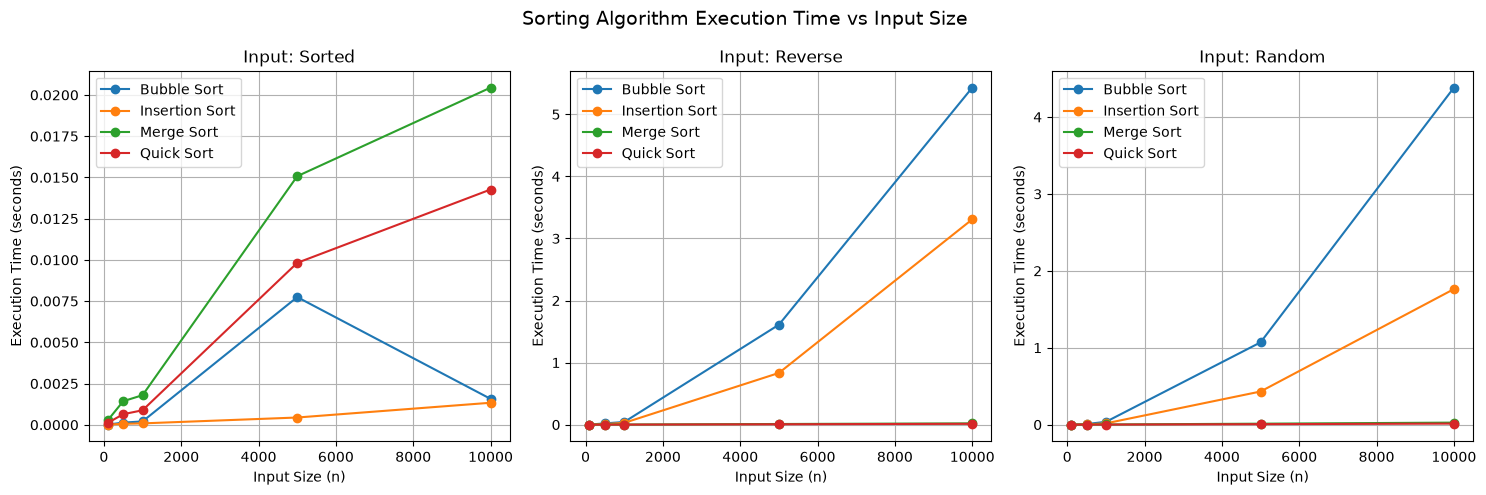

In [15]:
# Sorting Time Comparison (log scale)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sorting Algorithm Execution Time vs Input Size (Log Scale)', fontsize=14)

for idx, input_type in enumerate(['sorted', 'reverse', 'random']):
    ax = axes[idx]
    subset = sorting_df[sorting_df['Input Type'] == input_type]
    for algo in subset['Algorithm'].unique():
        d = subset[subset['Algorithm'] == algo]
        ax.plot(d['Input Size'], d['Execution Time (s)'], marker='o', label=algo)
    ax.set_xlabel('Input Size (n)')
    ax.set_ylabel('Execution Time (seconds)')
    ax.set_title(f'Input: {input_type.capitalize()}')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.7)

plt.tight_layout()
os.makedirs('../graphs', exist_ok=True)
plt.savefig('../graphs/sorting_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

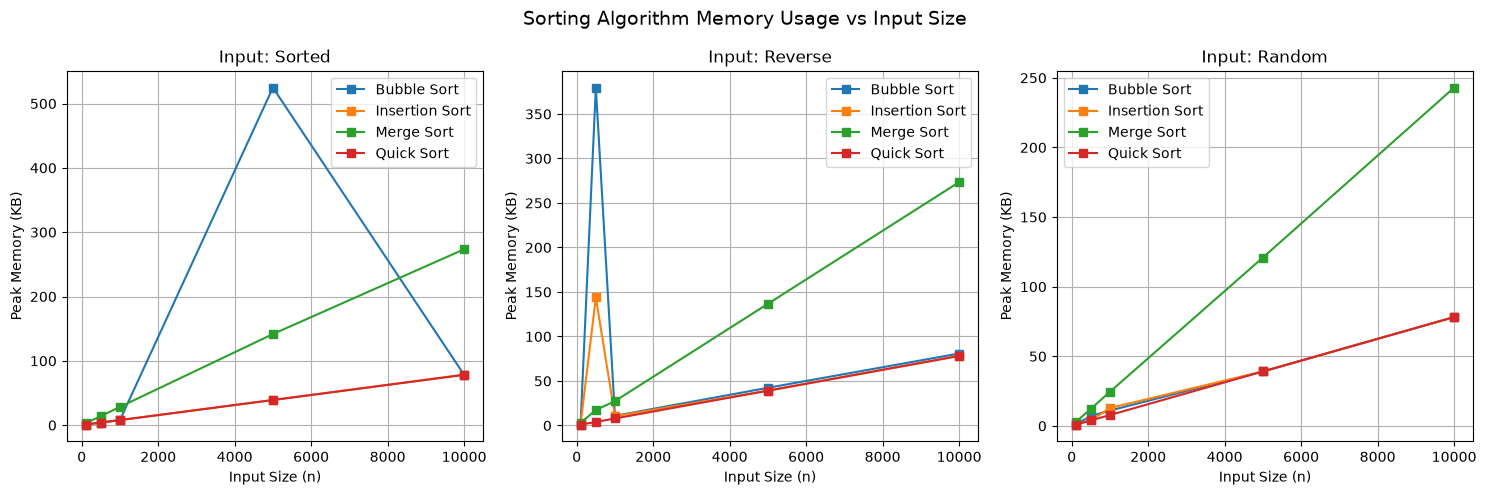

In [16]:
# Sorting Memory Comparison (log scale)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sorting Algorithm Memory Usage vs Input Size (Log Scale)', fontsize=14)

for idx, input_type in enumerate(['sorted', 'reverse', 'random']):
    ax = axes[idx]
    subset = sorting_df[sorting_df['Input Type'] == input_type]
    for algo in subset['Algorithm'].unique():
        d = subset[subset['Algorithm'] == algo]
        ax.plot(d['Input Size'], d['Memory Usage (KB)'], marker='s', label=algo)
    ax.set_xlabel('Input Size (n)')
    ax.set_ylabel('Peak Memory (KB)')
    ax.set_title(f'Input: {input_type.capitalize()}')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../graphs/sorting_memory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

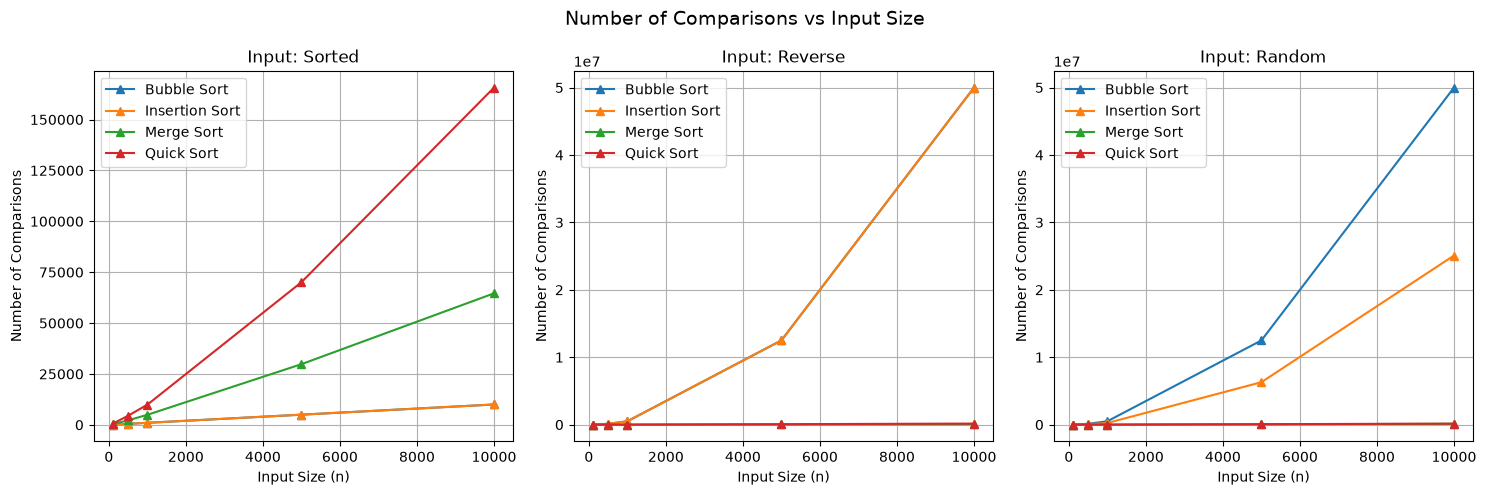

In [17]:
# Sorting Comparisons (log scale)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Number of Comparisons vs Input Size (Log Scale)', fontsize=14)

for idx, input_type in enumerate(['sorted', 'reverse', 'random']):
    ax = axes[idx]
    subset = sorting_df[sorting_df['Input Type'] == input_type]
    for algo in subset['Algorithm'].unique():
        d = subset[subset['Algorithm'] == algo]
        ax.plot(d['Input Size'], d['Comparisons'], marker='^', label=algo)
    ax.set_xlabel('Input Size (n)')
    ax.set_ylabel('Number of Comparisons')
    ax.set_title(f'Input: {input_type.capitalize()}')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../graphs/sorting_comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

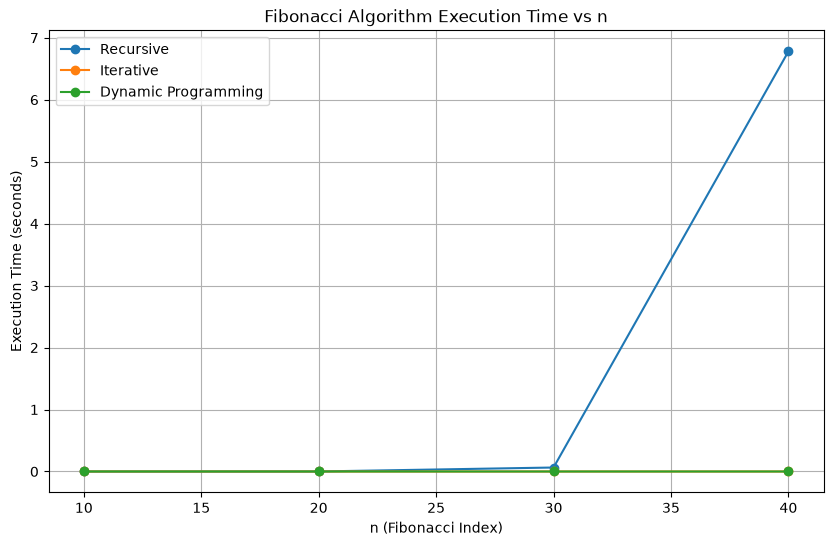

In [18]:
# Fibonacci Time Comparison
plt.figure(figsize=(10, 6))
for algo in fib_df['Algorithm'].unique():
    d = fib_df[fib_df['Algorithm'] == algo]
    plt.plot(d['n'], d['Execution Time (s)'], marker='o', label=algo)
plt.xlabel('n (Fibonacci Index)')
plt.ylabel('Execution Time (seconds)')
plt.title('Fibonacci Algorithm Execution Time vs n')
plt.legend()
plt.grid(True)
plt.savefig('../graphs/fibonacci_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

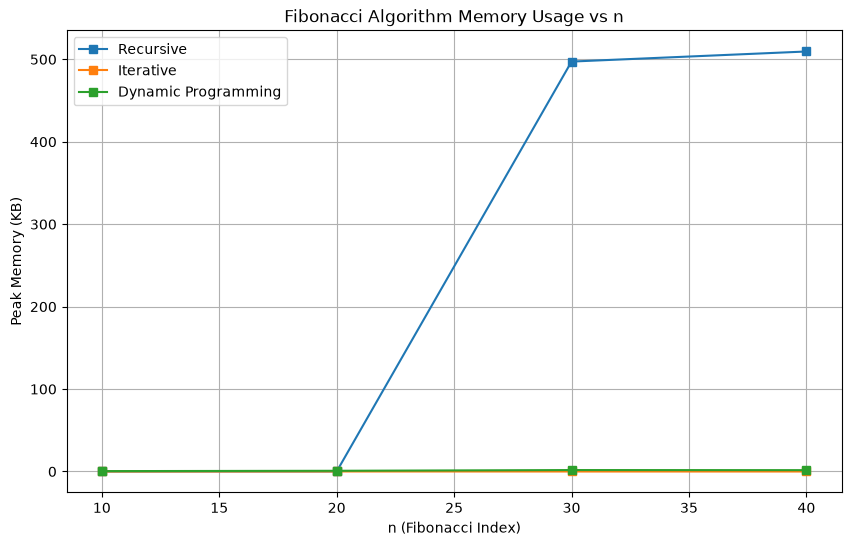

In [19]:
# Fibonacci Memory Comparison
plt.figure(figsize=(10, 6))
for algo in fib_df['Algorithm'].unique():
    d = fib_df[fib_df['Algorithm'] == algo]
    plt.plot(d['n'], d['Memory Usage (KB)'], marker='s', label=algo)
plt.xlabel('n (Fibonacci Index)')
plt.ylabel('Peak Memory (KB)')
plt.title('Fibonacci Algorithm Memory Usage vs n')
plt.legend()
plt.grid(True)
plt.savefig('../graphs/fibonacci_memory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Complexity Comparison Table

In [20]:
complexity_data = {
    'Algorithm': [
        'Bubble Sort', 'Insertion Sort', 'Merge Sort', 'Quick Sort',
        'Fibonacci (Recursive)', 'Fibonacci (Iterative)', 'Fibonacci (DP/Memo)'
    ],
    'Best Case': ['O(n)', 'O(n)', 'O(n log n)', 'O(n log n)', 'O(2ⁿ)', 'O(n)', 'O(n)'],
    'Average Case': ['O(n²)', 'O(n²)', 'O(n log n)', 'O(n log n)', 'O(2ⁿ)', 'O(n)', 'O(n)'],
    'Worst Case': ['O(n²)', 'O(n²)', 'O(n log n)', 'O(n²)', 'O(2ⁿ)', 'O(n)', 'O(n)'],
    'Space Complexity': ['O(1)', 'O(1)', 'O(n)', 'O(log n)', 'O(n)', 'O(1)', 'O(n)'],
}

complexity_df = pd.DataFrame(complexity_data)
complexity_df

,Algorithm,Best Case,Average Case,Worst Case,Space Complexity
0,Bubble Sort,O(n),O(n²),O(n²),O(1)
1,Insertion Sort,O(n),O(n²),O(n²),O(1)
2,Merge Sort,O(n log n),O(n log n),O(n log n),O(n)
3,Quick Sort,O(n log n),O(n log n),O(n²),O(log n)
4,Fibonacci (Recursive),O(2ⁿ),O(2ⁿ),O(2ⁿ),O(n)
5,Fibonacci (Iterative),O(n),O(n),O(n),O(1)
6,Fibonacci (DP/Memo),O(n),O(n),O(n),O(n)


---
## 8. Discussion

### Theoretical vs Practical Performance

1. **Bubble Sort and Insertion Sort** show O(n²) behavior - execution time grows quadratically with input size. On sorted data, both achieve O(n) due to early exit / no shifts.

2. **Merge Sort and Quick Sort** show O(n log n) behavior - much flatter growth curves, scalable to tens of thousands.

3. **Fibonacci Recursive** shows exponential growth (6.7s for n=40), while Iterative and DP complete in microseconds.

### Scalability
- Bubble Sort: Not usable beyond n ~ 10,000
- Insertion Sort: Not usable beyond n ~ 10,000
- Merge Sort: Scalable to n ~ 1,000,000+
- Quick Sort: Scalable to n ~ 1,000,000+
- Fibonacci Recursive: Not usable beyond n ~ 40
- Fibonacci Iterative/DP: Scalable to n ~ 1,000,000+

### Time-Space Trade-offs
- Merge Sort: O(n) extra space, but guaranteed O(n log n)
- Quick Sort: O(log n) space, but O(n²) worst case
- Fibonacci DP: O(n) space for memoization, but O(n) time

### Suitability Recommendations
- Small datasets (< 1000): Any algorithm works
- Large datasets: Use Merge Sort or Quick Sort
- Fibonacci: Always use Iterative or DP approach
- Online/streaming data: Use Insertion Sort

---
## 9. Save Data to CSV

In [21]:
os.makedirs('../data', exist_ok=True)
sorting_df.to_csv('../data/sorting_performance.csv', index=False)
fib_df.to_csv('../data/fibonacci_performance.csv', index=False)
print('Data saved to ../data/')

Data saved to ../data/
